# Step 1: Data Preparation

Prepare train and test data (Categorical and Numerical) and save to intermediate folder

- fill missing
- transformation
- encode categorical columns

In [11]:
import os
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

In [2]:
current_working_directory = os.getcwd()
home_dir = os.path.abspath(os.path.join(current_working_directory, os.pardir))
data_path = os.path.join(home_dir, 'data/')

In [6]:
# train
train_cat = pd.read_excel(os.path.join(data_path, 'TRAIN_NEW/TRAIN_CATEGORICAL_METADATA_new.xlsx'))
train_quant = pd.read_excel(os.path.join(data_path, 'TRAIN_NEW/TRAIN_QUANTITATIVE_METADATA_new.xlsx'))
# test
test_cat = pd.read_excel(os.path.join(data_path, 'TEST/TEST_CATEGORICAL.xlsx'))
test_quant = pd.read_excel(os.path.join(data_path, 'TEST/TEST_QUANTITATIVE_METADATA.xlsx'))

## 1. Categorical features

In [9]:
train_cat.isna().mean()

participant_id                      0.000000
Basic_Demos_Enroll_Year             0.000000
Basic_Demos_Study_Site              0.000000
PreInt_Demos_Fam_Child_Ethnicity    0.035449
PreInt_Demos_Fam_Child_Race         0.044518
MRI_Track_Scan_Location             0.002473
Barratt_Barratt_P1_Edu              0.012366
Barratt_Barratt_P1_Occ              0.025556
Barratt_Barratt_P2_Edu              0.163232
Barratt_Barratt_P2_Occ              0.183017
dtype: float64

In [11]:
# missing rate < 20%, fill
# Fill missing based on data dictionary
train_cat['PreInt_Demos_Fam_Child_Ethnicity'] = train_cat['PreInt_Demos_Fam_Child_Ethnicity'].fillna(3.0, inplace=True)
train_cat['PreInt_Demos_Fam_Child_Race'] = train_cat['PreInt_Demos_Fam_Child_Race'].fillna(10.0, inplace=True)

# Fill other missing with mode
col_to_fill = ['MRI_Track_Scan_Location','Barratt_Barratt_P1_Edu','Barratt_Barratt_P1_Occ','Barratt_Barratt_P2_Edu','Barratt_Barratt_P2_Occ']
for col in col_to_fill:
    mode = train_cat[col].mode()[0]
    train_cat[col].fillna(mode, inplace=True)

In [16]:
# check missing for test_cat
test_cat.isna().mean()

participant_id                      0.000000
Basic_Demos_Enroll_Year             0.000000
Basic_Demos_Study_Site              0.000000
PreInt_Demos_Fam_Child_Ethnicity    0.009868
PreInt_Demos_Fam_Child_Race         0.019737
MRI_Track_Scan_Location             0.000000
Barratt_Barratt_P1_Edu              0.003289
Barratt_Barratt_P1_Occ              0.003289
Barratt_Barratt_P2_Edu              0.118421
Barratt_Barratt_P2_Occ              0.138158
dtype: float64

In [17]:
# Fill missing based on data dictionary
test_cat['PreInt_Demos_Fam_Child_Ethnicity'] = test_cat['PreInt_Demos_Fam_Child_Ethnicity'].fillna(3.0, inplace=True)
test_cat['PreInt_Demos_Fam_Child_Race'] = test_cat['PreInt_Demos_Fam_Child_Race'].fillna(10.0, inplace=True)

# Fill other missing with mode
col_to_fill = ['Barratt_Barratt_P1_Edu','Barratt_Barratt_P1_Occ','Barratt_Barratt_P2_Edu','Barratt_Barratt_P2_Occ']
for col in col_to_fill:
    mode = test_cat[col].mode()[0]
    test_cat[col].fillna(mode, inplace=True)

In [ ]:
# one-hot encoder for categorical features
# Drop enroll year and study site as they come from different populations
for col in train_cat.select_dtypes(include=['float']).columns:
    train_cat[col] = train_cat[col].astype('category')

# create a list of all the columns except the first three
col_to_encode = train_cat.columns[3:].to_list()
len(col_to_encode)

7

In [13]:
# encode training set
encoder = OneHotEncoder(sparse=False, drop='first') # drop first to remove multicollinearity

encoded_train_cat = encoder.fit_transform(train_cat[col_to_encode])
encoded_train_cat_df = pd.DataFrame(encoded_train_cat, columns=encoder.get_feature_names_out(col_to_encode))
encoded_train_cat_df['participant_id'] = train_cat['participant_id']

In [14]:
encoded_train_cat_df.shape

(1213, 34)

In [20]:
col_to_encode

['PreInt_Demos_Fam_Child_Ethnicity',
 'PreInt_Demos_Fam_Child_Race',
 'MRI_Track_Scan_Location',
 'Barratt_Barratt_P1_Edu',
 'Barratt_Barratt_P1_Occ',
 'Barratt_Barratt_P2_Edu',
 'Barratt_Barratt_P2_Occ']

In [21]:
# Encode test set
encoder = OneHotEncoder(sparse=False, drop='first')
encoded_test_cat = encoder.fit_transform(test_cat[col_to_encode])
encoded_test_cat_df = pd.DataFrame(encoded_test_cat, columns=encoder.get_feature_names_out(col_to_encode))
encoded_test_cat_df['participant_id'] = test_cat['participant_id']
encoded_test_cat_df.shape

(304, 31)

In [22]:
# save to intermediate folder
encoded_train_cat_df.to_csv(os.path.join(data_path, 'intermediate/encoded_train_cat.csv'), index=False)
encoded_test_cat_df.to_csv(os.path.join(data_path, 'intermediate/encoded_test_cat.csv'), index=False)

## 2. Numeric columns

Check distribution of quantitative columns

In [23]:
train_quant.isna().mean()

participant_id                0.000000
EHQ_EHQ_Total                 0.010717
ColorVision_CV_Score          0.018961
APQ_P_APQ_P_CP                0.009893
APQ_P_APQ_P_ID                0.009893
APQ_P_APQ_P_INV               0.009893
APQ_P_APQ_P_OPD               0.009893
APQ_P_APQ_P_PM                0.009893
APQ_P_APQ_P_PP                0.009893
SDQ_SDQ_Conduct_Problems      0.007420
SDQ_SDQ_Difficulties_Total    0.007420
SDQ_SDQ_Emotional_Problems    0.007420
SDQ_SDQ_Externalizing         0.007420
SDQ_SDQ_Generating_Impact     0.007420
SDQ_SDQ_Hyperactivity         0.007420
SDQ_SDQ_Internalizing         0.007420
SDQ_SDQ_Peer_Problems         0.007420
SDQ_SDQ_Prosocial             0.007420
MRI_Track_Age_at_Scan         0.296785
dtype: float64

In [24]:
# fill missing values with medians
train_quant.fillna(train_quant.median(numeric_only=True), inplace=True)
test_quant.fillna(test_quant.median(numeric_only=True), inplace=True)

In [25]:
# save to intermediate folder
train_quant.to_csv(os.path.join(data_path, 'intermediate/train_quant_filled.csv'), index=False)
test_quant.to_csv(os.path.join(data_path, 'intermediate/test_quant_filled.csv'), index=False)

Transformation:

- Standardize on training quantitative features, as I plan to use linear models for feature selection
- Not transforming test set, as I plan to use tree-based model for model training, no need to do that for tree based models

In [26]:
# standardize train_quant for feature selection
scaler = StandardScaler()
train_quant_scaled = scaler.fit_transform(train_quant.drop(columns=['participant_id']))

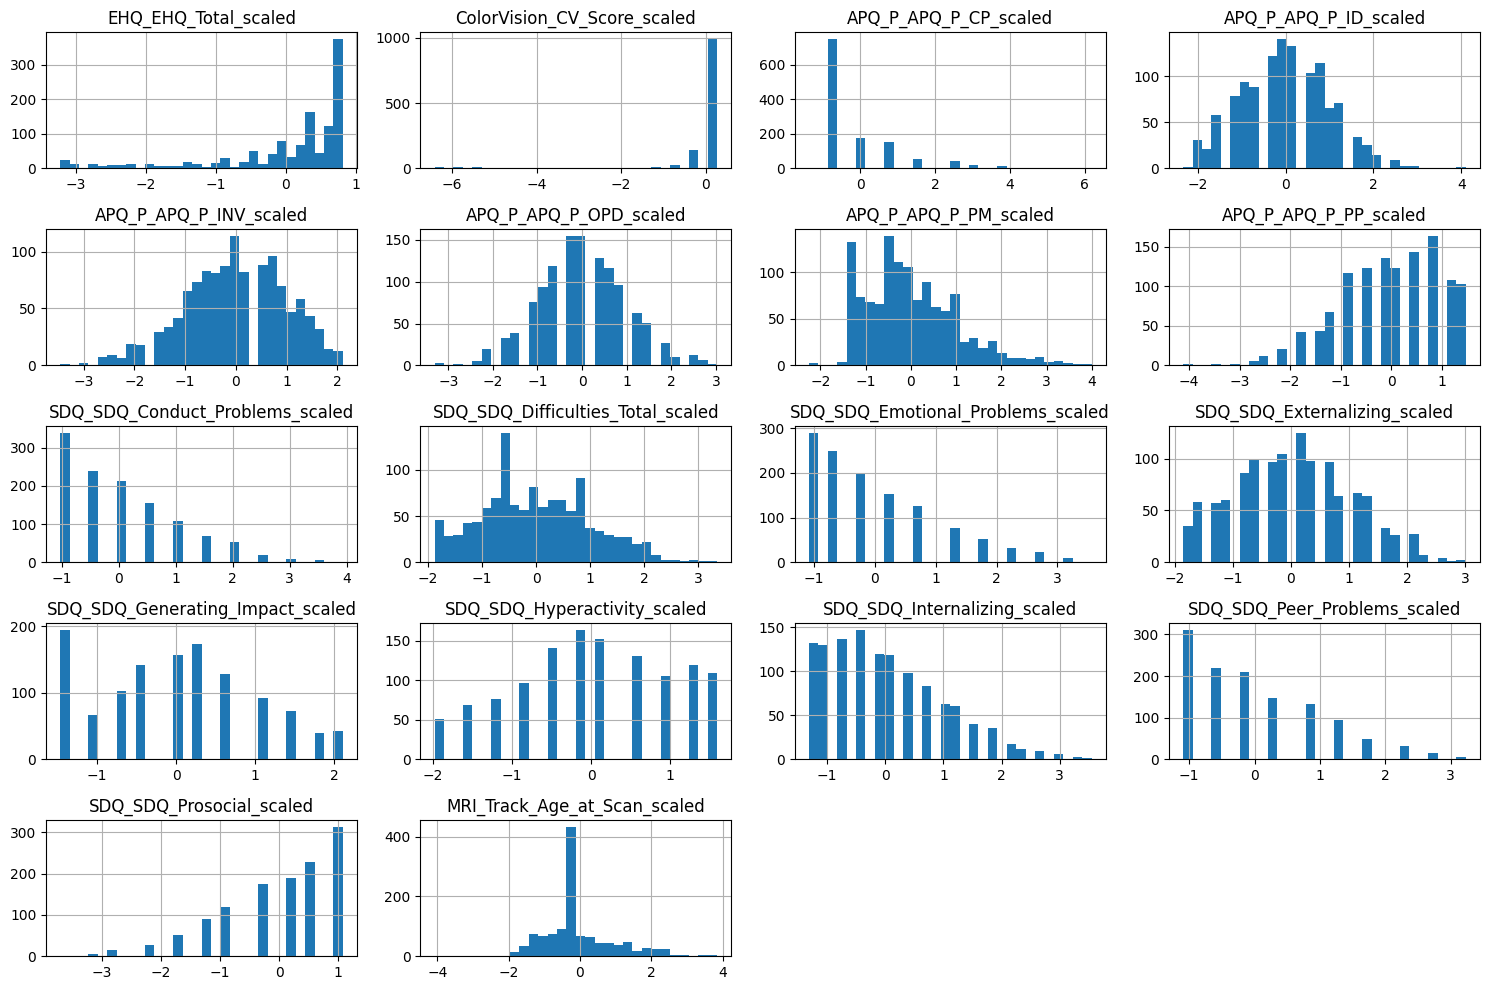

In [27]:
train_quant_scaled_df = pd.DataFrame(
    train_quant_scaled, 
    columns=[col + '_scaled' for col in train_quant.columns[1:]],
    index=train_quant.index)

train_quant_scaled_df.hist(bins=30, figsize=(15, 10), layout=(5, 4))
plt.tight_layout()
plt.show()

In [30]:
train_quant_scaled_df['participant_id'] = train_quant['participant_id']

In [31]:
train_quant_scaled_df.to_csv(os.path.join(data_path, 'intermediate/train_quant_scaled.csv'), index=False)

## 2. High Dimensional Data Input

In [3]:
train_func_connectome = pd.read_csv(os.path.join(data_path, 'TRAIN_NEW/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv'))

In [4]:
test_func_connectome = pd.read_csv(os.path.join(data_path, 'TEST/TEST_FUNCTIONAL_CONNECTOME_MATRICES.csv'))

In [7]:
train_func_connectome.shape

(1213, 19901)

In [5]:
test_func_connectome.shape

(304, 19901)

### Correlation matrix

In [34]:
# Compute the correlation matrix
corr_matrix = func_connectome_input.corr(method='spearman')
# corr_matrix

In [ ]:
sns.heatmap(corr_matrix, cmap='Blues')
plt.title('Correlation Matrix')
plt.show()

KeyboardInterrupt: 

### PCA 

In [9]:
train_connectome = train_func_connectome.drop(columns=['participant_id'])
test_connectone = test_func_connectome.drop(columns=['participant_id'])

In [21]:
# Run PCA on training set
pca = PCA(n_components=500)
pca.fit(train_connectome)                  # Fit PCA only on training data
train_pca = pca.transform(train_connectome)

# PCA on test data
test_pca = pca.transform(test_connectone) # Only transform!

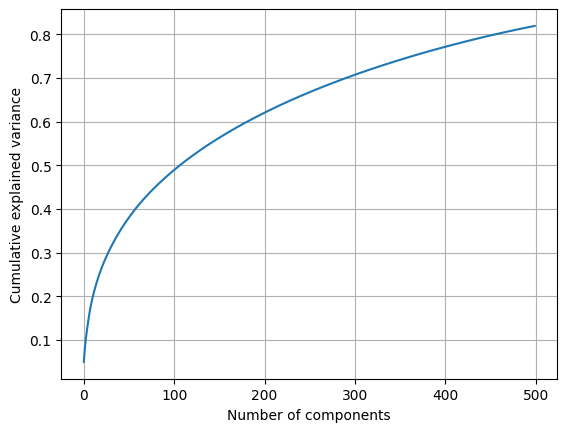

In [14]:
import matplotlib.pyplot as plt

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.grid()
plt.show()

In [22]:
# save 100 and 500 components
train_pca = pd.DataFrame(train_pca, columns=[f'PC{i+1}' for i in range(train_pca.shape[1])])
train_pca['participant_id'] = train_func_connectome['participant_id']
train_pca.to_csv(os.path.join(data_path, 'intermediate/train_pca_500.csv'), index=False)

In [23]:
test_pca = pd.DataFrame(test_pca, columns=[f'PC{i+1}' for i in range(test_pca.shape[1])])
test_pca['participant_id'] = test_func_connectome['participant_id']
test_pca.to_csv(os.path.join(data_path, 'intermediate/test_pca_500.csv'), index=False)

In [24]:
print(train_pca.shape, test_pca.shape)

(1213, 501) (304, 501)
